(200, 1)


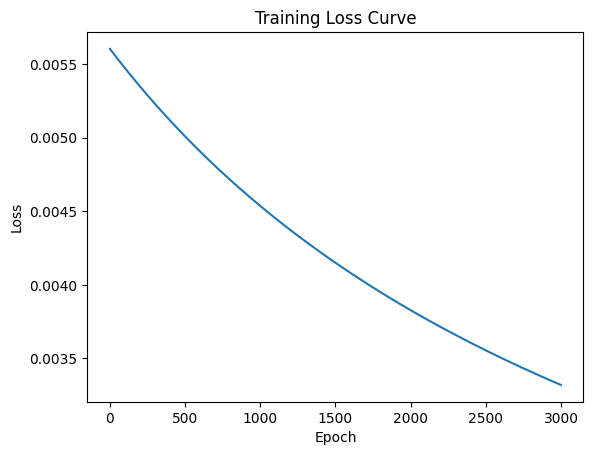

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. 样本数量
n_samples = 200
n_inf = n_samples // 2
n_norm = n_samples - n_inf

# 2. 构建 12 个基因表达矩阵
# 炎症组 
IL6_inf   = np.random.normal(loc=12, scale=3, size=100)
TNF_inf   = np.random.normal(loc=10, scale=2, size=100)
CXCL8_inf = np.random.normal(loc=14, scale=3, size=100)

KLF2_inf  = np.random.normal(loc=4, scale=1, size=100)
PPARG_inf = np.random.normal(loc=5, scale=1, size=100)
S1PR1_inf = np.random.normal(loc=3, scale=1, size=100)
noise_inf = [np.random.normal(8, 2, 100) for _ in range(6)]

X_inf = np.column_stack([
    IL6_inf, TNF_inf, CXCL8_inf,
    KLF2_inf, PPARG_inf, S1PR1_inf,
    *noise_inf
])

# 炎症组的标签为1（正类），所以标签集y要化为1向量
y_inf = np.ones((100,1))

# 健康组（Normal = 0）
IL6_norm   = np.random.normal(loc=6, scale=2, size=100)
TNF_norm   = np.random.normal(loc=5, scale=2, size=100)
CXCL8_norm = np.random.normal(loc=7, scale=2, size=100)

KLF2_norm  = np.random.normal(loc=8, scale=1, size=100)
PPARG_norm = np.random.normal(loc=9, scale=1, size=100)
S1PR1_norm = np.random.normal(loc=7, scale=1, size=100)

# Gene7–Gene12（6 个噪声基因）
noise_norm = [np.random.normal(loc=8, scale=2, size=100) for _ in range(6)]

# 拼接
X_norm = np.column_stack([
    IL6_norm, TNF_norm, CXCL8_norm,
    KLF2_norm, PPARG_norm, S1PR1_norm,
    *noise_norm
])

# 健康组标签为0（非正类），所以标签集要化为0向量
y_norm = np.zeros((100,1))

X = np.concatenate((X_inf,X_norm),axis = 0)

y = np.concatenate((y_inf,y_norm),axis = 0)

print(y.shape)
theta = np.zeros((X.shape[1],1))

# sigmoid函数 
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))


epochs = 3000
lr = 0.01
for epoch in range(epochs):
    z = X @ theta
    y_hat = sigmoid(z)
    error = y_hat - y
    grad = (1 / X.shape[0])*(X.T @ error)
    theta -= lr*grad


losses = []
for epoch in range(epochs):
    z = X @ theta
    y_hat = sigmoid(z)
    error = y_hat - y
    grad = (1 / X.shape[0]) * (X.T @ error)
    theta -= lr * grad
    
    # 交叉熵损失
    loss = -(1/X.shape[0]) * np.sum(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8))
    losses.append(loss)

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()


In [2]:
m, n = X.shape
theta = np.zeros((n,1))
lr = 0.01
lam = 0.1
epochs = 1000

losses = []

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    # 预测值 (逻辑回归)
    y_hat = sigmoid(X @ theta)
    
    # 损失函数 (交叉熵 + L2正则化)
    loss = -(1/m) * np.sum(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8)) \
           + (lam/(2*m)) * np.sum(theta**2)
    losses.append(loss)
    
    # 梯度 (交叉熵 + L2正则化)
    grad = (1/m) * (X.T @ (y_hat - y)) + (lam/m) * theta
    
    # 参数更新
    theta -= lr * grad
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss:.4f}")


Epoch 0, Loss = 0.6931
Epoch 100, Loss = 0.0542
Epoch 200, Loss = 0.0335
Epoch 300, Loss = 0.0256
Epoch 400, Loss = 0.0213
Epoch 500, Loss = 0.0185
Epoch 600, Loss = 0.0166
Epoch 700, Loss = 0.0151
Epoch 800, Loss = 0.0139
Epoch 900, Loss = 0.0129


✅ 推荐的更稳妥写法（排除偏置项）
如果你打算显式加 bias 列（第一列全是 1），建议这样写：

```python
# 损失函数 (交叉熵 + L2正则化，不含偏置项)
loss = -(1/m) * np.sum(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8)) \
       + (lam/(2*m)) * np.sum(theta[1:]**2)

# 梯度 (交叉熵 + L2正则化，不含偏置项)
grad = (1/m) * (X.T @ (y_hat - y))
grad[1:] += (lam/m) * theta[1:]
```

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 12 is different from 2)

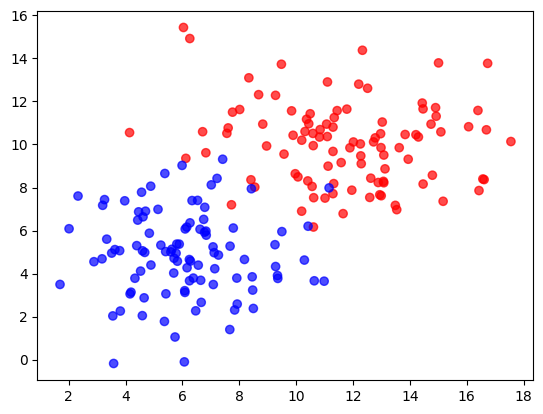

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 假设已经训练好 theta (shape = (2,1))
# 如果有偏置项，theta 应该是 (3,1)，X 要加一列全1

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 绘制数据点
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='bwr', alpha=0.7)

# 生成网格点
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# 计算预测值
grid = np.c_[xx.ravel(), yy.ravel()]
probs = sigmoid(grid @ theta).reshape(xx.shape)

# 绘制决策边界 (预测概率=0.5)
plt.contour(xx, yy, probs, levels=[0.5], cmap="Greys")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.show()


你报的这个错是因为 训练时用的是 12 个特征的参数 θ，而你在绘制决策边界时只生成了二维网格点 (xx, yy)，维度不匹配：

theta 的形状是 (12,1)

grid 的形状是 (N,2)

所以 grid @ theta 会报错：2 和 12 对不上。

🔎 为什么会这样
决策边界只能在二维空间里画出来。如果你的数据是 12 维的，就没法直接画二维边界。要画图，你必须：

只取两个特征（例如 IL6 和 TNF），训练一个二维逻辑回归模型；

或者用降维方法（比如 PCA）把 12 维数据压缩到 2 维，再画边界。

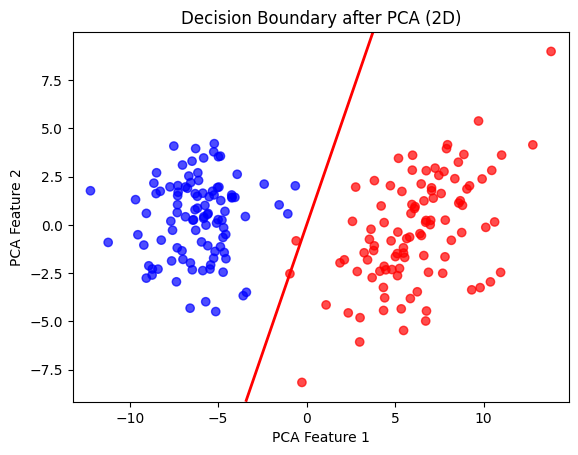

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)

# -----------------------------
# 1. 构建数据集 (200样本, 12特征)
# -----------------------------
n_samples = 200

# 炎症组 (100个样本)
IL6_inf   = np.random.normal(loc=12, scale=3, size=100)
TNF_inf   = np.random.normal(loc=10, scale=2, size=100)
CXCL8_inf = np.random.normal(loc=14, scale=3, size=100)
KLF2_inf  = np.random.normal(loc=4, scale=1, size=100)
PPARG_inf = np.random.normal(loc=5, scale=1, size=100)
S1PR1_inf = np.random.normal(loc=3, scale=1, size=100)
noise_inf = [np.random.normal(8, 2, 100) for _ in range(6)]

X_inf = np.column_stack([
    IL6_inf, TNF_inf, CXCL8_inf,
    KLF2_inf, PPARG_inf, S1PR1_inf,
    *noise_inf
])
y_inf = np.ones((100,1))

# 健康组 (100个样本)
IL6_norm   = np.random.normal(loc=6, scale=2, size=100)
TNF_norm   = np.random.normal(loc=5, scale=2, size=100)
CXCL8_norm = np.random.normal(loc=7, scale=2, size=100)
KLF2_norm  = np.random.normal(loc=8, scale=1, size=100)
PPARG_norm = np.random.normal(loc=9, scale=1, size=100)
S1PR1_norm = np.random.normal(loc=7, scale=1, size=100)
noise_norm = [np.random.normal(8, 2, size=100) for _ in range(6)]

X_norm = np.column_stack([
    IL6_norm, TNF_norm, CXCL8_norm,
    KLF2_norm, PPARG_norm, S1PR1_norm,
    *noise_norm
])
y_norm = np.zeros((100,1))

# 合并数据
X = np.concatenate((X_inf, X_norm), axis=0)
y = np.concatenate((y_inf, y_norm), axis=0)

# -----------------------------
# 2. PCA降维到二维
# -----------------------------
pca = PCA(n_components=2)
X2 = pca.fit_transform(X)   # (200,2)

# -----------------------------
# 3. 逻辑回归训练 (手写 + L2正则化)
# -----------------------------
m, n = X2.shape
theta = np.zeros((n,1))
lr = 0.01
lam = 0.1
epochs = 2000

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

losses = []
for epoch in range(epochs):
    y_hat = sigmoid(X2 @ theta)
    loss = -(1/m) * np.sum(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8)) \
           + (lam/(2*m)) * np.sum(theta**2)
    losses.append(loss)
    
    grad = (1/m) * (X2.T @ (y_hat - y)) + (lam/m) * theta
    theta -= lr * grad

# -----------------------------
# 4. 绘制决策边界
# -----------------------------
x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
probs = sigmoid(grid @ theta).reshape(xx.shape)

plt.scatter(X2[:,0], X2[:,1], c=y.ravel(), cmap='bwr', alpha=0.7)
plt.contour(xx, yy, probs, levels=[0.5], colors="red", linewidths=2)
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.title("Decision Boundary after PCA (2D)")
plt.show()


Epoch 0, Loss = 0.6931
Epoch 100, Loss = 0.0549
Epoch 200, Loss = 0.0343
Epoch 300, Loss = 0.0265
Epoch 400, Loss = 0.0222
Epoch 500, Loss = 0.0195
Epoch 600, Loss = 0.0175
Epoch 700, Loss = 0.0161
Epoch 800, Loss = 0.0149
Epoch 900, Loss = 0.0140


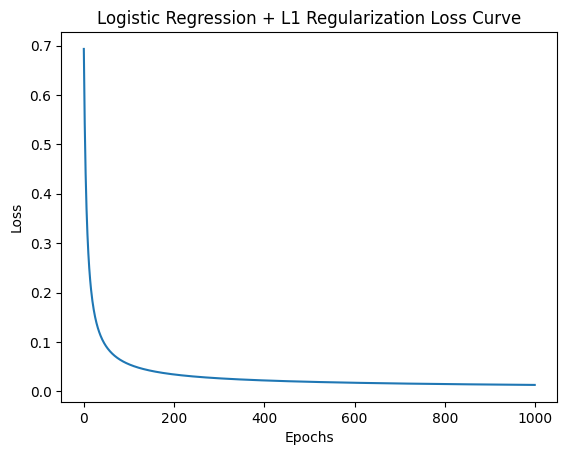

Final parameters theta:
[ 0.31065456  0.46356117  0.33924178 -0.43019806 -0.5362968  -0.53463711
 -0.00820308 -0.00662405  0.06824326 -0.07988863  0.00802194 -0.06021368]


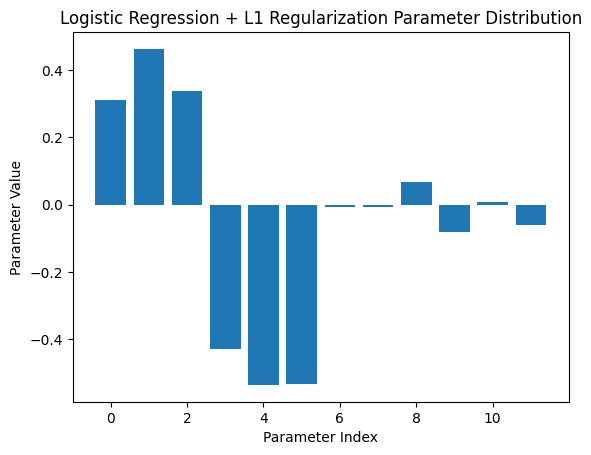

Training accuracy: 1.0000


In [5]:
import numpy as np


m, n = X.shape
theta = np.zeros((n,1))
lr = 0.01
lam = 0.1
epochs = 1000

losses = []

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    # 预测值
    y_hat = sigmoid(X @ theta)
    
    # 损失函数 (交叉熵 + L1正则化)
    loss = -(1/m) * np.sum(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8)) \
           + (lam/m) * np.sum(np.abs(theta[1:]))   # 偏置项不正则化
    losses.append(loss)
    
    # 梯度 (交叉熵 + L1正则化)
    grad = (1/m) * (X.T @ (y_hat - y))
    grad[1:] += (lam/m) * np.sign(theta[1:])      # L1正则化用符号函数
    
    # 参数更新
    theta -= lr * grad
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss:.4f}")

import matplotlib.pyplot as plt

# Plot loss curve
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Logistic Regression + L1 Regularization Loss Curve")
plt.show()

print("Final parameters theta:")
print(theta.ravel())

# Plot parameter distribution
plt.bar(range(len(theta)), theta.ravel())
plt.xlabel("Parameter Index")
plt.ylabel("Parameter Value")
plt.title("Logistic Regression + L1 Regularization Parameter Distribution")
plt.show()

# Accuracy
y_pred_label = (y_hat >= 0.5).astype(int)
acc = np.mean(y_pred_label == y)
print(f"Training accuracy: {acc:.4f}")

X shape: (200, 3)
y shape: (200, 1)


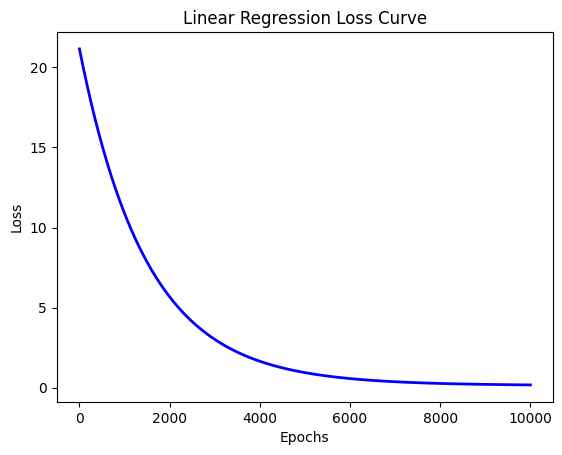

Learned parameters: [-0.00951554  2.89940565  1.8123924 ]


In [13]:
import numpy as np

np.random.seed(42)  # 保证可复现

# 样本数
m = 200  

# 两个特征
X1 = np.random.randn(m, 1) * 2
X2 = np.random.randn(m, 1) * 1.5

# 真实关系: y = 3*X1 + 2*X2 + 噪声

noise = np.random.randn(m, 1) * 0.5
y = 3*X1 + 2*X2 + noise

# 拼接成矩阵 (加偏置项)
X = np.hstack([np.ones((m,1)), X1, X2])  # shape (200,3)

print("X shape:", X.shape)
print("y shape:", y.shape)


theta = np.zeros((X.shape[1],1))
lr = 0.0001
epochs = 10000
losses = []

for epoch in range(epochs):
    y_hat = X @ theta
    error = y_hat - y
    loss = (1/(2*m)) * np.sum(error**2)      # MSE 损失
    losses.append(loss)
    grad = (1 / X.shape[0]) *(X.T @ error)
    theta -= lr * grad
    

# 绘制损失曲线 
plt.plot(losses, color="blue", linewidth=2) 
plt.xlabel("Epochs") 
plt.ylabel("Loss") 
plt.title("Linear Regression Loss Curve") 
plt.show()
print("Learned parameters:", theta.ravel())




In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
    
theta = np.zeros((X.shape[1],1))
lam = 0.01
lr = 0.0001
epochs = 10000
losses = []

for epoch in range(epochs):
    y_hat = sigmoid(X @ theta)
    
    # 损失函数 (交叉熵 + L2正则化)
    loss = -(1/m) * np.sum(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8)) \
           + (lam/(2*m)) * np.sum(theta**2)
    losses.append(loss)

     # 梯度 (交叉熵 + L2正则化)
    grad = (1/m) * (X.T @ (y_hat - y)) + (lam/m) * theta
    
    # 参数更新
    theta -= lr * grad
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss:.4f}")

# 绘制损失曲线 
plt.plot(losses, color="blue", linewidth=2) 
plt.xlabel("Epochs") 
plt.ylabel("Loss") 
plt.title("Logistic Regression with L2 Regularization - Loss Curve") 
plt.show() 
    

🔎 逐步检查

损失函数部分

L2 正则化部分：你这里对所有参数都加了正则化，包括偏置项。

如果 X 第一列是偏置项（全 1），通常 不对偏置项正则化。

更标准的写法是：

```python
+ (lam/(2*m)) * np.sum(theta[1:]**2)
```

梯度部分

同样需要注意偏置项：标准做法是只对 theta[1:] 加正则化：

```python
grad = (1/m) * (X.T @ (y_hat - y))
grad[1:] += (lam/m) * theta[1:]
```

✅ 改进后的标准写法
```python
# 损失函数 (交叉熵 + L2正则化，不含偏置项)
loss = -(1/m) * np.sum(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8)) \
       + (lam/(2*m)) * np.sum(theta[1:]**2)

# 梯度 (交叉熵 + L2正则化，不含偏置项)
grad = (1/m) * (X.T @ (y_hat - y))
grad[1:] += (lam/m) * theta[1:]
```

Epoch 0, Loss = 0.576185
Epoch 200, Loss = 0.009288
Epoch 400, Loss = 0.002026
Epoch 600, Loss = 0.001742
Epoch 800, Loss = 0.001597
Epoch 1000, Loss = 0.001469
Epoch 1200, Loss = 0.001353
Epoch 1400, Loss = 0.001248
Epoch 1600, Loss = 0.001154
Epoch 1800, Loss = 0.001069
估计的 β: [ 0.89301529  0.40810145  0.18466224 -0.03095484]


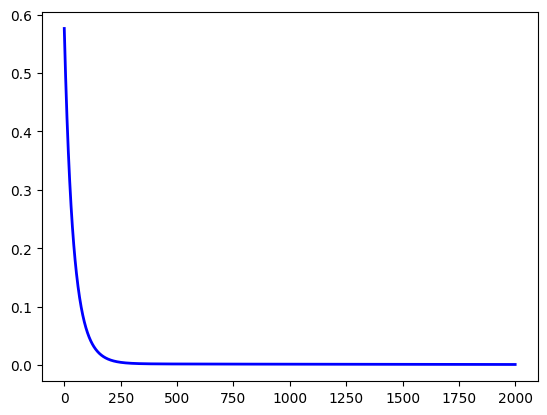

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1) 构造模拟数据（请替换为你的真实测量矩阵）
# ==========================
np.random.seed(42)

# 假设我们有 K 个蛋白，每个蛋白测 3 个稀释倍数（1x, 2x, 4x），每个倍数做 2 次重复
K = 10
dilutions = np.array([1.0, 0.5, 0.25])  # 稀释后浓度比例（1x，2x，4x）
reps = 2

# 总样本数 m
m = K * len(dilutions) * reps

# 假设“真实”未稀释浓度（仅用于模拟生成数据），真实场景中你没有这个量
true_conc_per_protein = np.random.uniform(0.5, 2.0, size=K)

rows = []
for pid in range(K):
    for d in dilutions:
        for r in range(reps):
            # 模拟A320为小背景散射
            A320 = np.random.uniform(0.00, 0.10)
            # 模拟A280与浓度线性相关，外加噪声与背景
            A280 = (true_conc_per_protein[pid] * d) * 1.2 + A320 + np.random.normal(0, 0.02)
            # 模拟A260有核酸污染的影响
            A260 = (true_conc_per_protein[pid] * d) * 0.15 + np.random.normal(0, 0.02)
            rows.append([A280, A260, A320])

X_raw = np.array(rows)         # 形状 (m, 3)，列依次为 [A280, A260, A320]
A280 = X_raw[:, 0]
A260 = X_raw[:, 1]
A320 = X_raw[:, 2]

# 标签（代理浓度）：y = A280 - A320
y = A280 - A320  # 形状 (m,)

# ==========================
# 2) 标准化特征（列方向）
# ==========================
X_feat = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

# 加截距列
X = np.column_stack([np.ones(m), X_feat])  # 形状 (m, 1+3)

# ==========================
# 3) 初始化参数与超参数
# ==========================
n = X.shape[1]          # n = 4 (β0, β1, β2, β3)
beta = np.zeros(n)      # β 初始化为 0
lr = 0.01               # 学习率（可调：0.01~0.1）
lam = 0.1               # 正则化系数（可扫：0.0, 0.01, 0.1, 1.0）
epochs = 2000
losses = []

# ==========================
# 4) 纯 for 梯度下降（不封装）
# ==========================
for epoch in range(epochs):
    # 预测
    y_hat = X @ beta
    err = y_hat - y

    # 损失（注意β0不正则化）
    loss = (1/(2*m)) * np.sum(err**2) + (lam/(2*m)) * np.sum(beta[1:]**2)
    losses.append(loss)

    # 梯度：先计算普通项
    grad = (1/m) * (X.T @ err)
    # 再对非截距项加正则化梯度
    grad[1:] += (lam/m) * beta[1:]

    # 参数更新
    beta -= lr * grad

    # 观测收敛
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss = {loss:.6f}")

print("估计的 β:", beta)

plt.plot(losses, color="blue", linewidth=2)
plt.show()

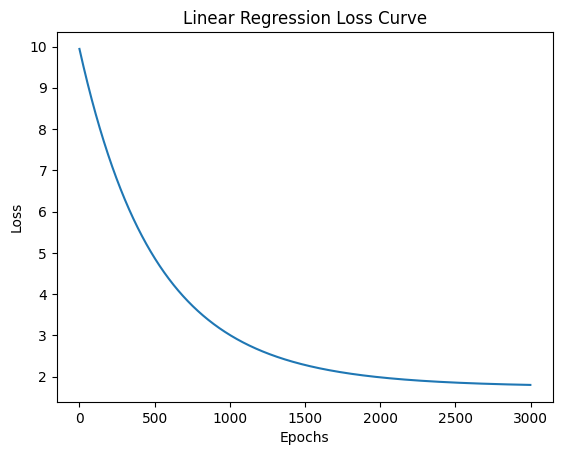

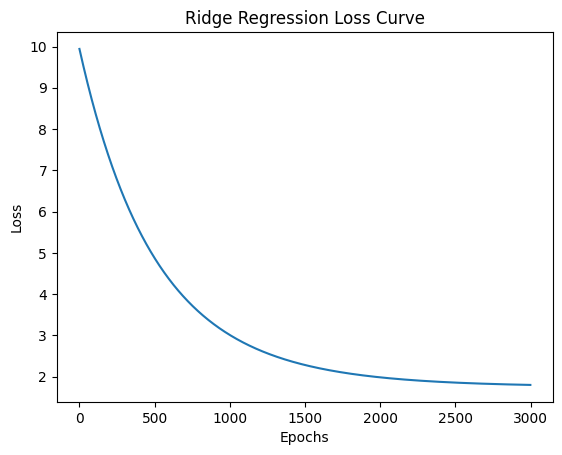

Epoch 3000
交叉熵梯度:
 [[ 1.97052819e-03 -1.73192565e-03  1.08067622e-03  1.99059697e-04
   1.99897640e-03 -1.37168524e-03 -2.45548637e-02  1.96838997e-02
  -1.23183773e-02 -2.76052760e-02  2.28498172e-02 -9.97658682e-04
   1.15546293e-03  1.24488230e-03 -7.31234357e-04 -7.24142409e-04
  -6.58518983e-04  3.70800269e-04  5.67688142e-04  1.44722090e-03
  -1.36139528e-05]]
L1 正则化梯度:
 [[ 0.          0.00033333  0.00033333 -0.00033333 -0.00033333  0.00033333
   0.00033333 -0.00033333  0.00033333  0.00033333 -0.00033333  0.00033333
  -0.00033333 -0.00033333 -0.00033333  0.00033333 -0.00033333 -0.00033333
  -0.00033333  0.00033333 -0.00033333]]
总梯度:
 [[ 1.97052819e-03 -1.39859232e-03  1.41400955e-03 -1.34273636e-04
   1.66564306e-03 -1.03835191e-03 -2.42215304e-02  1.93505663e-02
  -1.19850439e-02 -2.72719427e-02  2.25164839e-02 -6.64325348e-04
   8.22129601e-04  9.11548968e-04 -1.06456769e-03 -3.90809076e-04
  -9.91852316e-04  3.74669356e-05  2.34354809e-04  1.78055424e-03
  -3.46947286e-04]]
--

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. 构建模拟数据
n_samples = 300
n_genes = 20

# 基因表达矩阵
X = np.random.normal(0, 1, (n_samples, n_genes))

# 肿瘤大小（连续变量，基因1-5决定）
tumor_size = X[:,0]*2 + X[:,1]*1.5 + X[:,2]*(-1) + X[:,3]*0.5 + X[:,4]*3 \
+ np.random.normal(0, 2, n_samples)

# 肿瘤是否恶性（分类变量，基因6-10决定）
logits = ( 
    X[:,5]*2 
    + X[:,6]*(-1.5) 
    + X[:,7]*1 
    + X[:,8]*2.5 
    + X[:,9]*(-2)
)

prob = 1 / (1 + np.exp(-logits))

y_class = (prob > 0.5).astype(int)



# 目标变量（形状统一为 (N,1)） 
y_reg = tumor_size.reshape(-1, 1) # 线性回归的 y 

y_clf = y_class.reshape(-1, 1) # 逻辑回归的 y

# 2. 标准化
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

# 添加截距列（两种任务都会用到） 
X_lin = np.hstack([np.ones((n_samples,1)), X_scaled]) # 线性回归设计矩阵 

X_log = np.hstack([np.ones((n_samples,1)), X_scaled]) # 逻辑回归设计矩阵 

# 3. 线性回归 vs Ridge 回归

# TODO: 实现普通线性回归 (梯度下降)
# TODO: 实现 Ridge 回归 (加上 λ * ||w||^2)


# 梯度下降
lr = 0.001
epochs = 3000
theta = np.zeros((X_lin.shape[1],1))
losses = []
for epoch in range(epochs):
    y_hat = X_lin @ theta
    error = y_hat - y_reg
    loss = (1/(2*X_lin.shape[0])) * np.sum(error**2)
    losses.append(loss)
    grad = 1 / X_lin.shape[0] *(X_lin.T @ error)
    theta -= lr*grad

plt.plot(losses) 
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Linear Regression Loss Curve")
plt.show()


#Ridge 回归
m = X_lin.shape[0]
lr = 0.001
epochs = 3000
lam = 0.1
theta = np.zeros((X_lin.shape[1],1))
losses = []
for epoch in range(epochs):
    y_hat = X_lin @ theta
    error = y_hat - y_reg
    
    # 损失函数：1/(2m) MSE + (lam/(2m)) L2（不惩罚截距） 
    loss = (1/(2*m)) * np.sum(error**2) + (lam/(2*m)) * np.sum(theta[1:]**2) 
    losses.append(loss) 
    
    # 梯度：普通部分 + 正则化部分（不惩罚截距） 
    grad = (1/m) * (X_lin.T @ error) + (lam/m) * theta 
    grad[0] = (1/m) * (X_lin[:,0].T @ error) # 截距项不惩罚
    
    # 参数更新 
    theta -= lr * grad
plt.plot(losses) 
plt.xlabel("Epochs") 
plt.ylabel("Loss") 
plt.title("Ridge Regression Loss Curve") 
plt.show()



# 4. 逻辑回归 vs Lasso 回归
# TODO: 实现普通逻辑回归 (梯度下降)
# TODO: 实现 Lasso 回归 (加上 λ * ||w||_1)

# 先定义 sigmoid 函数
def sigmoid(theta):
    return 1 / (1 + np.exp(-theta))
theta = np.zeros((X_log.shape[1],1))
lr = 0.01
epochs = 3000
losses = []
for epoch in range(epochs):
    z = X_log @ theta
    y_hat = sigmoid(z)
    error = y_hat - y_clf
    
    # 损失函数：交叉熵 + L1 正则化 
    loss = -(1/m) * np.sum(y_clf*np.log(y_hat+1e-8) + (1-y_clf)*np.log(1-y_hat+1e-8)) \
          + (lam/m) * np.sum(np.abs(theta[1:]))
    losses.append(loss)

    # 普通交叉熵梯度 
    grad_ce = (1/m) * (X_log.T @ error)
    
    # L1 正则化梯度（不惩罚截距） 
    grad_l1 = np.zeros_like(theta) 
    grad_l1[1:] = (lam/m) * np.sign(theta[1:])
    
    # 总梯度 = 两部分相加 
    grad_total = grad_ce + grad_l1

    # 参数更新
    theta -= lr*grad_total

# 打印查看两个梯度
print(f"Epoch {epoch+1}") 
print("交叉熵梯度:\n", grad_ce.T) 
print("L1 正则化梯度:\n", grad_l1.T) 
print("总梯度:\n", grad_total.T) 
print("-"*50)

# 5. 可视化
# TODO: 绘制 loss 曲线
# TODO: 绘制权重条形图


**截距项的处理方式**
**你写的是：**

```python
grad = (1/m) * (X_lin.T @ error) + (lam/m) * theta 
grad[0] = (1/m) * (X_lin[:,0].T @ error)  # 截距项不惩罚
```
**这逻辑是对的：先算普通梯度 + 正则化，再把截距项覆盖掉，保证截距不受正则化影响。**

**更简洁的写法是直接在正则化时跳过截距：**

```python
grad = (1/m) * (X_lin.T @ error)
grad[1:] += (lam/m) * theta[1:]
```
**这样不用先加再覆盖，逻辑更清晰。**

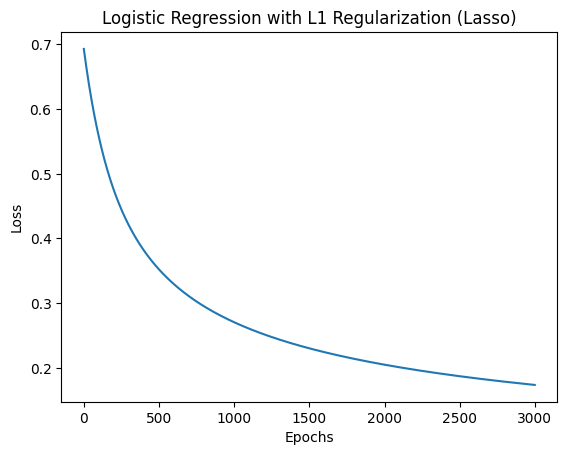

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid 函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 初始化参数
theta = np.zeros((X_log.shape[1],1))
lr = 0.01
epochs = 3000
lam = 0.1   # L1 正则化强度
losses = []

m = X_log.shape[0]

for epoch in range(epochs):
    # 预测概率
    z = X_log @ theta
    y_hat = sigmoid(z)
    error = y_hat - y_clf
    
    # 损失函数：交叉熵 + L1 正则化（不惩罚截距）
    loss = -(1/m) * np.sum(y_clf*np.log(y_hat+1e-8) + (1-y_clf)*np.log(1-y_hat+1e-8)) \
           + (lam/m) * np.sum(np.abs(theta[1:]))
    losses.append(loss)
    
    # 梯度：普通部分 + L1 正则化部分（符号函数，不惩罚截距）
    grad = (1/m) * (X_log.T @ error)
    grad[1:] += (lam/m) * np.sign(theta[1:])
    
    # 参数更新
    theta -= lr * grad

# 可视化损失曲线
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Logistic Regression with L1 Regularization (Lasso)")
plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

theta = np.zeros((X_log.shape[1],1))
lr = 0.01
epochs = 10   # 这里先用少量迭代方便查看
lam = 0.1
m = X_log.shape[0]

for epoch in range(epochs):
    z = X_log @ theta
    y_hat = sigmoid(z)
    error = y_hat - y_clf
    
    # 损失函数：交叉熵 + L1 正则化
    loss = -(1/m) * np.sum(y_clf*np.log(y_hat+1e-8) + (1-y_clf)*np.log(1-y_hat+1e-8)) \
           + (lam/m) * np.sum(np.abs(theta[1:]))
    
    # 普通交叉熵梯度
    grad_ce = (1/m) * (X_log.T @ error)
    
    # L1 正则化梯度（不惩罚截距）
    grad_l1 = np.zeros_like(theta)
    grad_l1[1:] = (lam/m) * np.sign(theta[1:])
    
    # 总梯度 = 两部分相加
    grad_total = grad_ce + grad_l1
    
    # 参数更新
    theta -= lr * grad_total
    
    # 打印查看两个梯度
    print(f"Epoch {epoch+1}")
    print("交叉熵梯度:\n", grad_ce.T)
    print("L1 正则化梯度:\n", grad_l1.T)
    print("总梯度:\n", grad_total.T)
    print("-"*50)


Epoch 1
交叉熵梯度:
 [[ 0.01       -0.0175044  -0.06398738  0.01499428  0.0166365  -0.00889411
  -0.21782589  0.17974263 -0.10718448 -0.21596295  0.16463643 -0.02486176
   0.03488041 -0.0268705   0.01955489 -0.01564322  0.0491119  -0.00139313
  -0.00416788 -0.03067343  0.02339475]]
L1 正则化梯度:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
总梯度:
 [[ 0.01       -0.0175044  -0.06398738  0.01499428  0.0166365  -0.00889411
  -0.21782589  0.17974263 -0.10718448 -0.21596295  0.16463643 -0.02486176
   0.03488041 -0.0268705   0.01955489 -0.01564322  0.0491119  -0.00139313
  -0.00416788 -0.03067343  0.02339475]]
--------------------------------------------------
Epoch 2
交叉熵梯度:
 [[ 0.009975   -0.01748454 -0.06369732  0.01495194  0.016648   -0.00885172
  -0.21722872  0.17921743 -0.1069297  -0.21540362  0.16419346 -0.02481653
   0.03474244 -0.02673348  0.01945039 -0.01560476  0.04890089 -0.00137054
  -0.00410442 -0.03057615  0.02330523]]
L1 正则化梯度:
 [[ 0.          0.00033333  0.0003333

In [1]:

import numpy as np

np.random.seed(2026)

# ---- 参数设置 ----
n_samples = 500       # 样本数
n_genes = 100         # 基因总数
modules = {
    "prolif": 20,     # 增殖模块
    "immune": 20,     # 免疫模块
    "metab": 20,      # 代谢模块
    "emt": 20,        # EMT模块
    "house": 20       # 管家模块
}
assert sum(modules.values()) == n_genes

# 相关性（同模块内的相关系数）
rho_by_module = {
    "prolif": 0.6,
    "immune": 0.5,
    "metab": 0.4,
    "emt": 0.5,
    "house": 0.1
}

# ---- 构造块相关协方差矩阵并采样 ----
X_blocks = []
labels = []
for name, p in modules.items():
    rho = rho_by_module[name]
    # 协方差矩阵：对角为1，非对角为rho
    cov = (1 - rho) * np.eye(p) + rho * np.ones((p, p))
    # 多元正态采样（均值0）
    block = np.random.multivariate_normal(mean=np.zeros(p), cov=cov, size=n_samples)
    X_blocks.append(block)
    labels += [name] * p

X = np.hstack(X_blocks)  # (N, 100)

# ---- 混杂：批次效应与年龄 ----
# 批次：A/B 两批，各占一半；给某些模块加偏移
batch = np.zeros((n_samples, 1))
batch[int(n_samples/2):] = 1  # 后半为批次B
# 给批次B在代谢模块上加偏移，在免疫模块上减偏移（模拟平台差异）
metab_idx = np.where(np.array(labels) == "metab")[0]
immune_idx = np.where(np.array(labels) == "immune")[0]
X[:, metab_idx] += batch * 0.5
X[:, immune_idx] -= batch * 0.3

# 年龄：正态分布，影响连续/分类表型
age = np.random.normal(60, 10, size=(n_samples, 1))  # 均值60，方差10

# ---- 标准化（基因表达按列标准化） ----
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=1)
X_scaled = (X - X_mean) / (X_std + 1e-8)

# ---- 生物学设定的权重 ----
# 连续表型：IC50/增殖速度 ~ +prolif +metab -immune + age/批次 + 噪声
w_prolif = 2.0
w_metab  = 1.5
w_immune = -2.5
# 分类表型：恶性/转移 ~ +emt +prolif -immune + age/批次
w_emt    = 2.0
w_prolif_cls = 1.0
w_immune_cls = -1.5

# 将模块权重分配至各基因（同模块内随机扰动）
def module_weight(vec_idx, base_w):
    # 每个基因围绕base权重做小扰动，制造稀疏/不均匀
    w = base_w + np.random.normal(0, 0.3, size=len(vec_idx))
    # 稀疏化：只让其中约30%真正起作用
    mask = (np.random.rand(len(vec_idx)) < 0.3).astype(float)
    return w * mask

w_reg = np.zeros(n_genes)
w_reg[ np.where(np.array(labels)=="prolif")[0] ] += module_weight(np.where(np.array(labels)=="prolif")[0], w_prolif)
w_reg[ np.where(np.array(labels)=="metab")[0]  ] += module_weight(np.where(np.array(labels)=="metab")[0],  w_metab)
w_reg[ np.where(np.array(labels)=="immune")[0] ] += module_weight(np.where(np.array(labels)=="immune")[0], w_immune)

# 连续表型（加协变量与噪声）
noise = np.random.normal(0, 2.0, size=(n_samples,))
y_reg = X_scaled.dot(w_reg) + 0.02 * age[:,0] + 0.5 * batch[:,0] + noise
y_reg = y_reg.reshape(-1, 1)

# 分类表型 logits
w_cls = np.zeros(n_genes)
w_cls[ np.where(np.array(labels)=="emt")[0] ]    += module_weight(np.where(np.array(labels)=="emt")[0],    w_emt)
w_cls[ np.where(np.array(labels)=="prolif")[0] ] += module_weight(np.where(np.array(labels)=="prolif")[0], w_prolif_cls)
w_cls[ np.where(np.array(labels)=="immune")[0] ] += module_weight(np.where(np.array(labels)=="immune")[0], w_immune_cls)

logits = X_scaled.dot(w_cls) + 0.01 * age[:,0] + 0.3 * batch[:,0]
prob = 1 / (1 + np.exp(-logits))
y_clf = (prob > 0.5).astype(int).reshape(-1, 1)

# ---- 设计矩阵（含截距与不希望被正则的协变量列） ----
# 约定：前3列为 [intercept, batch, age]，其余为基因表达
X_design = np.hstack([np.ones((n_samples,1)), batch, age, X_scaled])

print("X_design:", X_design.shape)  # (N, 3+100)
print("y_reg:", y_reg.shape)
print("y_clf:", y_clf.shape)


X_design: (500, 103)
y_reg: (500, 1)
y_clf: (500, 1)


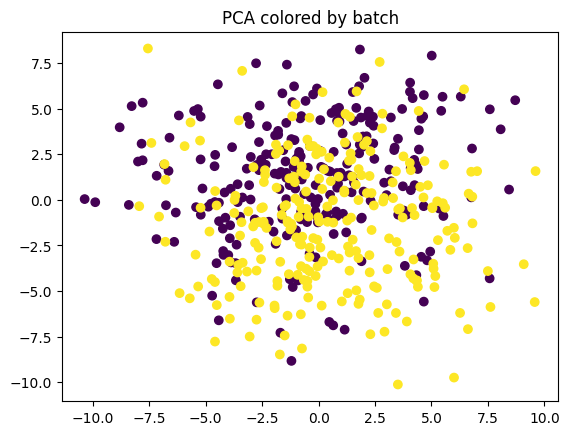

R2: 0.9894642397997662
MSE: 2.994975447469451


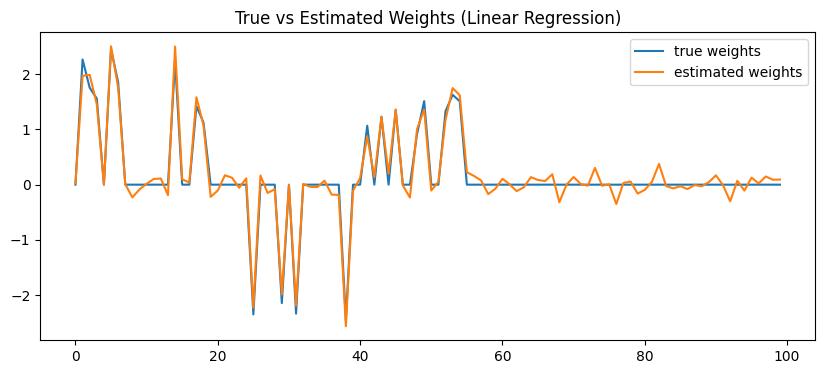

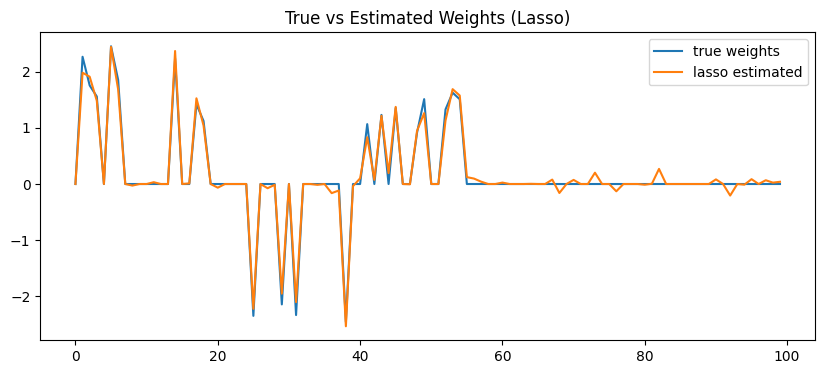

In [4]:
import numpy as np

np.random.seed(2026)

# ---- 参数设置 ----
n_samples = 500
n_genes = 100
modules = {
    "prolif": 20,
    "immune": 20,
    "metab": 20,
    "emt": 20,
    "house": 20
}


assert sum(modules.values()) == n_genes


# 相关性（同模块内的相关系数）
rho_by_module = {
    "prolif": 0.6,
    "immune": 0.5,
    "metab": 0.4,
    "emt": 0.5,
    "house": 0.1
}

# ---- 构造块相关协方差矩阵并采样 ----
X_blocks = []                                            # 每个模块的基因表达块
labels = []                                              # 基因标签列表
for name, p in modules.items():                          # 模块名与基因数
    rho = rho_by_module[name]                            # 相关系数
    
    # 协方差矩阵：对角为1，非对角为rho
    cov = (1 - rho) * np.eye(p) + rho * np.ones((p, p))  # 协方差矩阵
    
    # 多元正态采样（均值0）
    block = np.random.multivariate_normal(mean=np.zeros(p), cov=cov, size=n_samples)  # 采样
    X_blocks.append(block)                                                            # 添加到块列表
    labels += [name] * p                                                              # 基因标签列表扩展

X = np.hstack(X_blocks)
X.shape


batch = np.zeros((n_samples, 1))                     # 批次向量初始化，前 250 个样本属于 批次 A（batch = 0）
batch[int(n_samples/2):] = 1                         # 后半为批次B， batch = 1

metab_idx = np.where(np.array(labels) == "metab")[0]      # 代谢模块基因索引
immune_idx = np.where(np.array(labels) == "immune")[0]    # 免疫模块基因索引

X[:, metab_idx] += batch * 0.5
X[:, immune_idx] -= batch * 0.3

age = np.random.normal(60, 10, size=(n_samples, 1))

X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=1)
X_scaled = (X - X_mean) / (X_std + 1e-8)


# ---- 将模块权重分配至各基因（同模块内随机扰动） ----
#第一步：定义模块权重分配函数
def module_weight(vec_idx, base_w):
    # 每个基因围绕 base_w 做小扰动
    w = base_w + np.random.normal(0, 0.3, size=len(vec_idx))
    # 稀疏化：只让其中约30%真正起作用
    mask = (np.random.rand(len(vec_idx)) < 0.3).astype(float)
    return w * mask

# 第二步：构造连续表型的权重向量 w_reg
w_reg = np.zeros(n_genes)

# 增殖模块
w_reg[np.where(np.array(labels)=="prolif")[0]] += module_weight(
    np.where(np.array(labels)=="prolif")[0], base_w=2.0)

# 代谢模块
w_reg[np.where(np.array(labels)=="metab")[0]] += module_weight(
    np.where(np.array(labels)=="metab")[0], base_w=1.5)

# 免疫模块
w_reg[np.where(np.array(labels)=="immune")[0]] += module_weight(
    np.where(np.array(labels)=="immune")[0], base_w=-2.5)


# 第三步：构造分类表型的权重向量 w_cls
w_cls = np.zeros(n_genes)

# EMT模块
w_cls[np.where(np.array(labels)=="emt")[0]] += module_weight(
    np.where(np.array(labels)=="emt")[0], base_w=2.0)

# 增殖模块
w_cls[np.where(np.array(labels)=="prolif")[0]] += module_weight(
    np.where(np.array(labels)=="prolif")[0], base_w=1.0)

# 免疫模块
w_cls[np.where(np.array(labels)=="immune")[0]] += module_weight(
    np.where(np.array(labels)=="immune")[0], base_w=-1.5)

# 第四步：生成表型
# 连续表型（回归）
noise = np.random.normal(0, 2.0, size=(n_samples,))
y_reg = X_scaled.dot(w_reg) + 0.02 * age[:,0] + 0.5 * batch[:,0] + noise
y_reg = y_reg.reshape(-1, 1)

# 分类表型（逻辑回归）
logits = X_scaled.dot(w_cls) + 0.01 * age[:,0] + 0.3 * batch[:,0]
prob = 1 / (1 + np.exp(-logits))
y_clf = (prob > 0.5).astype(int).reshape(-1, 1)





from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=batch[:,0])
plt.title("PCA colored by batch")
plt.show()

# 线性回归评估
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_scaled, y_reg)

y_pred = lr.predict(X_scaled)

print("R2:", r2_score(y_reg, y_pred))
print("MSE:", mean_squared_error(y_reg, y_pred))

# 绘制真实权重与估计权重对比
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(w_reg, label="true weights")
plt.plot(lr.coef_.flatten(), label="estimated weights")
plt.legend()
plt.title("True vs Estimated Weights (Linear Regression)")
plt.show()

# lasso回归评估
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.05)
lasso.fit(X_scaled, y_reg)

plt.figure(figsize=(10,4))
plt.plot(w_reg, label="true weights")
plt.plot(lasso.coef_, label="lasso estimated")
plt.legend()
plt.title("True vs Estimated Weights (Lasso)")
plt.show()
